In [1]:
#Imports + file discovery
import glob
import re
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import cumulative_trapezoid
from matplotlib.animation import FFMpegWriter, writers

In [ ]:
ls /data/RIS/cyuran/Active/giantflares/Aaron/Aperture4  

bin/              design.org*                    license-header.txt*  src/
build/            develop.Dockerfile*            logo_icon.png*       tests/
cmake/            develop.Dockerfile.archlinux*  machines/            todo.org*
CMakeLists.txt*   docs/                          problems/
CONTRIBUTING.md*  fix_permissions.sh*            python/
deps/             LICENSE*                       README.md*


In [2]:
run_meta = {
    "WALD, B0ss": {
        "display": "WALD_beta=1e4",
        "movie_rsr": "rho_sigma_rhoWALD_Bss.mp4",
        "movie_rb": "rho_betaWALD_Bss.mp4",
    },
    "WALD, B0s": {
        "display": "WALD_beta=1e3",
        "movie_rsr": "rho_sigma_rhoWALD_Bs.mp4",
        "movie_rb": "rho_betaWALD_Bs.mp4",
    },
    "WALD, B0": {
        "display": "WALD_beta=1e4",
        "movie_rsr": "rho_sigma_rhoWALD_Btest.mp4",
        "movie_rb": "rho_betaWALD_Btest.mp4",
    },
    "SANE, B0": {
        "display": "SANE_beta=1e2",
        "movie_rsr": "rho_sigma_rhoSANE.mp4",
        "movie_rb": "rho_betaSANE.mp4",
    },
}

# Canonicalize user-friendly selector strings (case/space-insensitive).
selector_aliases = {
    re.sub(r"\\s+", "", label.lower()): label
    for label in run_meta
}

In [3]:
runs_root = Path(".")

def _collect_runs_with_dumps(root):
    candidates = [root] + sorted(
        [path for path in root.iterdir() if path.is_dir()],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    runs = []
    for path in candidates:
        dumps = sorted(path.glob("torus.out0.*.phdf"))
        if dumps:
            runs.append((path, dumps))
    return runs

available_runs = _collect_runs_with_dumps(runs_root)
if not available_runs:
    raise FileNotFoundError(
        f"No torus.out0.*.phdf files found in {runs_root.resolve()} or its immediate subdirectories"
    )
print("Available runs with dumps:")
for idx, (path, dumps) in enumerate(available_runs):
    print(f"  [{idx:2d} ] {path} ({len(dumps)} dumps)")

Available runs with dumps:
  [ 0 ] wald2d_vec_a0.93_t2000_B0_20260316_103709 (164 dumps)
  [ 1 ] wald2d_vec_a0.93_t2000_B0s_20260318_145202 (201 dumps)
  [ 2 ] wald2d_vec_a0.93_t2000_B0ss_20260318_164142 (301 dumps)
  [ 3 ] sane2d_a0.93_t5000_B0_20260311_145650 (108 dumps)


In [ ]:
# "WALD, smoke": {
#         "display": "WALD_beta=1e2",
#         "movie_rsr": "rho_sigma_rhoSANE.mp4",
#         "movie_rb": "rho_betaSANE.mp4",
#     },

In [149]:
# Choose run to analyze:
#   None -> latest run (default)
#   int  -> index from the list above (supports negative indexing)
#   str  -> run name/path, glob pattern like "wald2d_vec*", or friendly labels like
#           "WALD, B0", "WALD, B0s", "WALD, B0ss", "SANE, B0"

run_selector = "SANE, B0"
selected_run = None
dump_files = []
run_selector_resolved = None
run_selector_key = None
run_dir = None
dump_file = None

def _setup_run_selector():
    """Initialize run selector with validation and resolution logic."""
    global run_selector_resolved, run_selector_key, selected_run, dump_files, run_dir, dump_file

    def _infer_selector_key_from_path(path):
        name = path.name.lower()
        if "sane" in name:
            return "SANE, B0"
        if "b0ss" in name:
            return "WALD, B0ss"
        if "b0s" in name:
            return "WALD, B0s"
        if "wald" in name:
            return "WALD, B0"
        return None

    def _resolve_selected_run(run_selector, available_runs, runs_root):
        run_selector_key = None

        if run_selector is None:
            selected_run, dump_files = available_runs[0]
            run_selector_resolved = 0
            run_selector_key = _infer_selector_key_from_path(selected_run)

        elif isinstance(run_selector, int):
            idx = run_selector if run_selector >= 0 else len(available_runs) + run_selector
            if idx < 0 or idx >= len(available_runs):
                raise IndexError(
                    f"run_selector={run_selector} is out of range for {len(available_runs)} available runs"
                )
            selected_run, dump_files = available_runs[idx]
            run_selector_resolved = idx
            run_selector_key = _infer_selector_key_from_path(selected_run)

        elif isinstance(run_selector, (str, Path)):
            selector_text = str(run_selector).strip()
            selector_key = re.sub(r"\\s+", "", selector_text.lower())
            matches = []

            if selector_key in selector_aliases:
                canonical = selector_aliases[selector_key]
                run_selector_key = canonical
                matches = [
                    (idx, path, dumps)
                    for idx, (path, dumps) in enumerate(available_runs)
                    if _infer_selector_key_from_path(path) == canonical
                ]
            elif any(ch in selector_text for ch in "*?[]"):
                matched_dirs = {
                    path.resolve() for path in runs_root.glob(selector_text) if path.is_dir()
                }
                matches = [
                    (idx, path, dumps)
                    for idx, (path, dumps) in enumerate(available_runs)
                    if path.resolve() in matched_dirs
                ]
            else:
                target = Path(selector_text)
                if not target.is_absolute():
                    target = runs_root / target
                target_resolved = target.resolve()
                matches = [
                    (idx, path, dumps)
                    for idx, (path, dumps) in enumerate(available_runs)
                    if path.resolve() == target_resolved
                    or path.name == selector_text
                    or str(path) == selector_text
                ]

            if not matches:
                valid_labels = ", ".join(run_meta.keys())
                example_runs = ", ".join(str(path) for path, _ in available_runs[:5])
                raise ValueError(
                    f"run_selector={run_selector!r} did not match any run with dumps. "
                    f"Valid friendly labels: {valid_labels}. Examples: {example_runs}"
                )

            # If multiple matches (e.g. glob/alias), keep newest by available_runs ordering.
            run_selector_resolved, selected_run, dump_files = matches[0]
            if run_selector_key is None:
                run_selector_key = _infer_selector_key_from_path(selected_run)
        else:
            raise TypeError("run_selector must be None, int, str, or Path")

        if run_selector_key not in run_meta:
            raise ValueError(
                f"Resolved run '{selected_run.name}' to unknown selector key {run_selector_key!r}. "
                f"Known keys: {', '.join(run_meta.keys())}"
            )

        run_dir = str(selected_run)

        # use final if present, else latest numbered dump
        dump_file = selected_run / "torus.out0.final.phdf"
        if dump_file not in dump_files and dump_files:
            dump_file = dump_files[-1]

        return run_selector_resolved, run_selector_key, selected_run, dump_files, run_dir, dump_file

    # Invoke resolution logic
    run_selector_resolved, run_selector_key, selected_run, dump_files, run_dir, dump_file = _resolve_selected_run(
        run_selector, available_runs, runs_root,
    )

    print("Using run directory:", selected_run.resolve())
    print(f"Resolved run_selector index: {run_selector_resolved}")
    print(f"Resolved run_selector key: {run_selector_key}")
    print(f"{len(dump_files)} dump files found")
    print("First:", dump_files[0])
    print("Last :", dump_files[-1])
    print("Using snapshot:", dump_file)

_setup_run_selector()

Using run directory: /home/aaron/Research/kharma/runs/sane2d_a0.93_t5000_B0_20260311_145650
Resolved run_selector index: 3
Resolved run_selector key: SANE, B0
108 dump files found
First: sane2d_a0.93_t5000_B0_20260311_145650/torus.out0.00000.phdf
Last : sane2d_a0.93_t5000_B0_20260311_145650/torus.out0.final.phdf
Using snapshot: sane2d_a0.93_t5000_B0_20260311_145650/torus.out0.final.phdf


In [150]:
hst_file = f"{run_dir}/torus.hst"

with open(hst_file, "r") as f:
    lines = f.readlines()

# Column names come from line like: [1]=time [2]=dt ...
header_line = next(line for line in lines if line.startswith("# [1]="))
col_names = [m[1] for m in re.findall(r"\[(\d+)\]=([A-Za-z0-9_]+)", header_line)]

df = pd.read_csv(hst_file, comment="#", sep=r"\s+", names=col_names)

In [151]:
print(df.head())
print(df.columns.tolist())

       time        dt       MaxDivB         Phi_0        Phi_EH        Phi_5M  \
0  0.000000  0.000010  6.661340e-14  0.000000e+00  0.000000e+00  0.000000e+00   
1  0.105157  0.032107  8.237850e-14  1.243590e-87  2.536550e-79  3.907110e-19   
2  0.201467  0.032119  7.599480e-14  1.725710e-74  1.436260e-67  1.546850e-18   
3  0.329812  0.032086  9.092730e-14  1.289840e-64  3.154820e-60  6.434780e-18   
4  0.426129  0.032023  8.526510e-14  4.191400e-61  1.160330e-56  1.944910e-17   

    FFlags     Mass     Egas   X1_Mom  ...  Mdot_Flux  Mdot_EH_Flux  \
0      0.0  25840.8  620.709  50805.7  ...   0.000000      0.000000   
1  11028.0  25840.8  620.709  50805.7  ...   0.000148      0.000143   
2  10996.0  25840.8  620.709  50805.7  ...   0.000149      0.000143   
3  10954.0  25840.8  620.709  50805.7  ...   0.000149      0.000143   
4  10928.0  25840.8  620.709  50805.7  ...   0.000148      0.000143   

   Mdot_5M_Flux  Edot_Flux  Edot_EH_Flux  Edot_5M_Flux   Ldot_0_Flux  \
0      0.00000

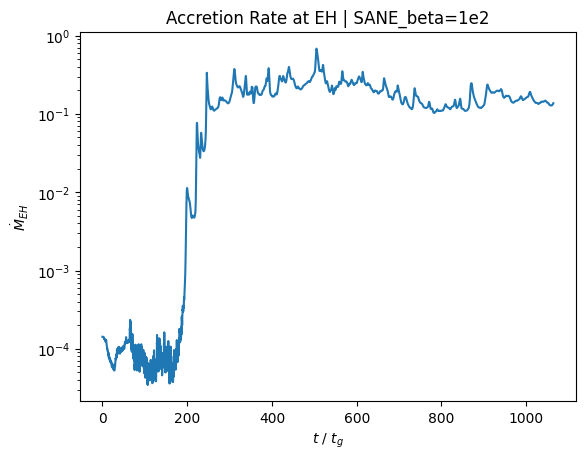

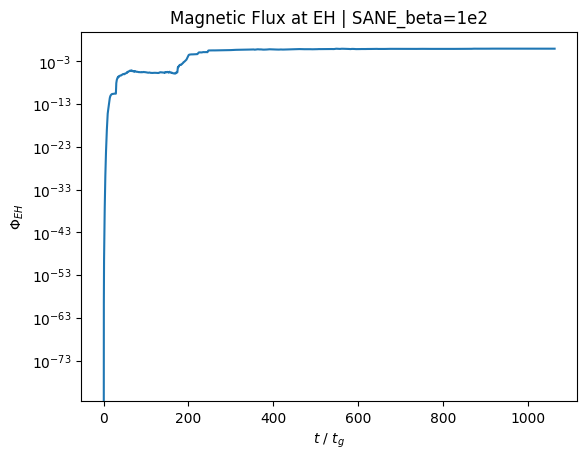

In [152]:
run_label = run_meta[run_selector_key]["display"]

plt.plot(df["time"], df["Mdot_EH"])
plt.xlabel(r"$t$ / $t_g$")
plt.ylabel(r"$\dot M_{EH}$")
plt.yscale("log")
plt.title(f"Accretion Rate at EH | {run_label}")
plt.show()

plt.plot(df["time"], df["Phi_EH"])
plt.xlabel(r"$t$ / $t_g$")
plt.ylabel(r"$\Phi_{EH}$")
plt.yscale("log")
plt.title(f"Magnetic Flux at EH | {run_label}")
plt.show()

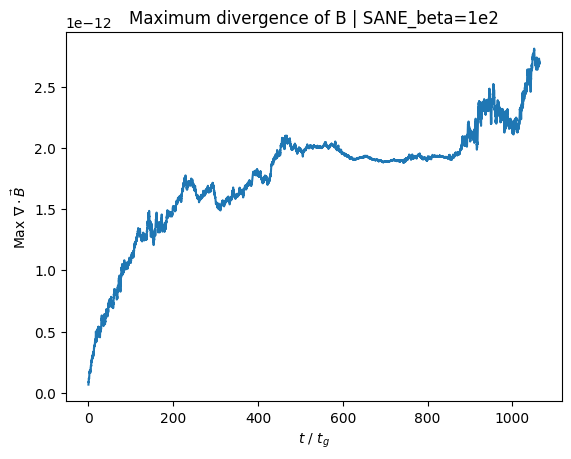

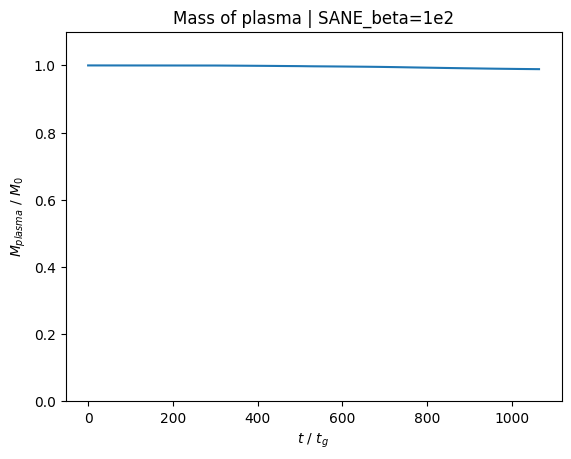

In [153]:
run_label = run_meta[run_selector_key]["display"]

plt.plot(df["time"], df["MaxDivB"])
plt.xlabel(r"$t$ / $t_g$")
plt.ylabel(r"Max $\nabla \cdot \vec B$")
# plt.yscale("log")
plt.title(f"Maximum divergence of B | {run_label}")
plt.show()

plt.plot(df["time"], df["Mass"]/df["Mass"][0])
plt.xlabel(r"$t$ / $t_g$")
plt.ylabel(r"$M_{plasma}$ / $M_0$")
# plt.yscale("log")
plt.ylim(0, 1.1)
plt.title(f"Mass of plasma | {run_label}")
plt.show()

In [154]:
with h5py.File(dump_file, "r") as f:
    # shapes from your xdmf:
    # prims.rho: (nblock, 1, n2, n1), Locations/x: (nblock, n1+1), Locations/y: (nblock, n2+1)
    rho_blk = f["prims.rho"][:, 0, :, :]      # (nblock, n2, n1)
    x_edges_blk = f["Locations/x"][:]          # (nblock, n1+1)
    y_edges_blk = f["Locations/y"][:]          # (nblock, n2+1)

# Order blocks by their y start, then concatenate in y
order = np.argsort(y_edges_blk[:, 0])
rho = np.concatenate([rho_blk[b] for b in order], axis=0)  # (N2, N1)

x_edges = x_edges_blk[order[0]]
y_edges = np.concatenate(
    [y_edges_blk[b][:-1] for b in order] + [y_edges_blk[order[-1]][-1:]]
)

print("rho shape:", rho.shape)
print("x_edges:", x_edges.shape, "y_edges:", y_edges.shape)

rho shape: (128, 128)
x_edges: (129,) y_edges: (129,)


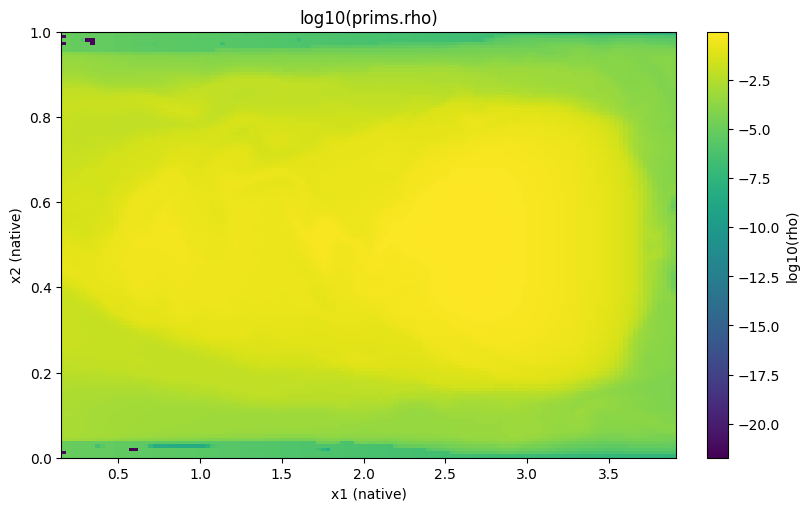

In [155]:
X, Y = np.meshgrid(x_edges, y_edges)
rho_log = np.log10(np.maximum(rho, 1e-30))

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
im = ax.pcolormesh(X, Y, rho_log, shading="auto", cmap="viridis")
ax.set_xlabel("x1 (native)")
ax.set_ylabel("x2 (native)")
ax.set_title("log10(prims.rho)")
plt.colorbar(im, ax=ax, label="log10(rho)")
plt.show()

In [156]:
def _parse_par_value(raw):
    text = raw.strip()
    low = text.lower()
    if low in {"true", "false"}:
        return low == "true"
    try:
        if any(ch in text for ch in [".", "e", "E"]):
            return float(text)
        return int(text)
    except ValueError:
        return text


def _read_par_file(par_file):
    params = {}
    if par_file is None or not par_file.exists():
        return params

    section = ""
    with open(par_file, "r", encoding="utf-8") as fp:
        for raw_line in fp:
            line = raw_line.split("#", 1)[0].strip()
            if not line:
                continue
            if line.startswith("<") and line.endswith(">"):
                section = line[1:-1].strip()
                continue
            if "=" not in line:
                continue
            key, val = [part.strip() for part in line.split("=", 1)]
            full_key = f"{section}/{key}" if section else key
            params[full_key] = _parse_par_value(val)
    return params


def _resolve_primitive(var_name):
    key = str(var_name).strip().lower()
    mapping = {
        "rho": ("prims.rho", None, "rho"),
        "u": ("prims.u", None, "u"),
        "uu": ("prims.u", None, "u"),
        "u1": ("prims.uvec", 0, "u1"),
        "u2": ("prims.uvec", 1, "u2"),
        "u3": ("prims.uvec", 2, "u3"),
        "b1": ("prims.B", 0, "B1"),
        "b2": ("prims.B", 1, "B2"),
        "b3": ("prims.B", 2, "B3"),
        "prims.rho": ("prims.rho", None, "rho"),
        "prims.u": ("prims.u", None, "u"),
        "prims.uvec1": ("prims.uvec", 0, "u1"),
        "prims.uvec2": ("prims.uvec", 1, "u2"),
        "prims.uvec3": ("prims.uvec", 2, "u3"),
        "prims.b1": ("prims.B", 0, "B1"),
        "prims.b2": ("prims.B", 1, "B2"),
        "prims.b3": ("prims.B", 2, "B3"),
        "beta": ("derived", None, "beta"),
        "sigma_rho": ("derived", None, "sigma_rho"),
        "sigma_w": ("derived", None, "sigma_w"),
    }
    if key not in mapping:
        valid = ["rho", "u", "u1", "u2", "u3", "B1", "B2", "B3", "beta", "sigma_rho", "sigma_w"]
        raise ValueError(
            f"Unknown primitive '{var_name}'. Available variables: {', '.join(valid)}"
        )
    return mapping[key]


def _slice_phi(arr, phi_index=0):
    if arr.ndim == 3:
        return arr
    if arr.ndim == 4:
        return arr[:, phi_index, :, :]
    raise ValueError(f"Unexpected array shape: {arr.shape}")


def _load_primitive_2d(fh, dataset_name, component=None, phi_index=0):
    if component is None:
        raw = fh[dataset_name][:]
    else:
        raw = fh[dataset_name][:, component, ...]
    return _slice_phi(raw, phi_index=phi_index)


def _extract_gdet_2d(fh, order, phi_index=0):
    if "coords.gdet" not in fh:
        return None
    gdet_blk = _slice_phi(fh["coords.gdet"][:], phi_index=phi_index)
    return np.concatenate([gdet_blk[b] for b in order], axis=0)


def _find_geometry_dump(dump_path):
    dump_path = Path(dump_path)
    parent = dump_path.parent

    first_dump = parent / "torus.out3.00000.phdf"
    if first_dump.exists():
        return first_dump

    numbered = sorted(parent.glob("torus.out3.[0-9][0-9][0-9][0-9][0-9].phdf"))
    if numbered:
        return numbered[0]

    final_dump = parent / "torus.out3.final.phdf"
    if final_dump.exists():
        return final_dump

    if ".out0." in dump_path.name:
        paired = parent / dump_path.name.replace(".out0.", ".out3.")
        if paired.exists():
            return paired

    for candidate in sorted(parent.glob("torus.out3.*.phdf")):
        if candidate.exists():
            return candidate
    return None


def _load_metric_gdet_2d(dump_path, order, phi_index=0):
    dump_path = Path(dump_path)
    with h5py.File(dump_path, "r") as fh:
        gdet_2d = _extract_gdet_2d(fh, order, phi_index=phi_index)
    if gdet_2d is not None:
        return gdet_2d

    geom_path = _find_geometry_dump(dump_path)
    if geom_path is None:
        return None

    with h5py.File(geom_path, "r") as fh:
        return _extract_gdet_2d(fh, order, phi_index=phi_index)

def _metric_flux_from_b1(
    b1_2d,
    y_centers,
    dump_path,
    order,
    phi_index=0,
    warn_on_fallback=False,
):
    gdet_2d = _load_metric_gdet_2d(dump_path, order, phi_index=phi_index)
    if gdet_2d is None:
        raise ValueError(
            "coords.gdet is unavailable for metric-consistent contours. "
            "Generate/use a geometry dump with valid coords.gdet values."
        )
    if gdet_2d.shape != b1_2d.shape:
        raise ValueError(
            f"coords.gdet shape {gdet_2d.shape} does not match B1 shape {b1_2d.shape}"
        )
    if not np.isfinite(gdet_2d).any() or np.allclose(gdet_2d, 0.0):
        raise ValueError(
            "coords.gdet is invalid (all non-finite or all zeros), so "
            "metric-consistent magnetic contours cannot be computed."
        )

    integrand = gdet_2d * b1_2d
    return cumulative_trapezoid(integrand, x=y_centers, axis=0, initial=0.0)

def _compute_beta_sigma(rho_2d, u_2d, b1_2d, b2_2d, b3_2d, gamma=4.0/3.0, eps=1e-30):
    """
    Compute plasma beta and magnetization diagnostics from primitives.

    Parameters
    ----------
    rho_2d : ndarray
        Rest-mass density (2D)
    u_2d : ndarray
        Internal energy density (2D)
    b1_2d, b2_2d, b3_2d : ndarray
        3-magnetic field components (each 2D)
    gamma : float, optional
        Adiabatic index. Default: 4/3.
    eps : float, optional
        Small floor to avoid divide-by-zero.

    Returns
    -------
    beta : ndarray
        Plasma beta = P / (0.5 * b^2)
    sigma_rho : ndarray
        Magnetization relative to density = b^2 / rho
    sigma_w : ndarray
        Magnetization relative to enthalpy = b^2 / w, where w = rho + u + P
    bsq : ndarray
        Magnetic field strength b^2 = b1^2 + b2^2 + b3^2
    """
    P = (gamma - 1.0) * u_2d
    w = rho_2d + u_2d + P
    bsq = b1_2d**2 + b2_2d**2 + b3_2d**2 

    beta = P / (0.5 * bsq + eps)
    sigma_rho = bsq / (rho_2d + eps)
    sigma_w = bsq / (w + eps)

    return beta, sigma_rho, sigma_w, bsq

def _native_to_r_theta(x1, x2, coord_cfg):
    hslope = float(coord_cfg.get("hslope", 0.3))
    transform = str(coord_cfg.get("transform", "mks")).lower()
    r = np.exp(x1)

    theta_g = np.pi * x2 + 0.5 * (1.0 - hslope) * np.sin(2.0 * np.pi * x2)
    theta = theta_g

    if transform == "fmks":
        mks_smooth = float(coord_cfg.get("mks_smooth", 0.5))
        poly_xt = float(coord_cfg.get("poly_xt", 0.82))
        poly_alpha = float(coord_cfg.get("poly_alpha", 14.0))
        startx1 = float(coord_cfg.get("startx1", 0.0))

        y = 2.0 * x2 - 1.0
        ratio = y / poly_xt
        alpha_rounded = int(round(poly_alpha))
        if abs(poly_alpha - alpha_rounded) < 1e-10:
            ratio_pow = ratio ** alpha_rounded
        else:
            ratio_pow = np.power(np.abs(ratio), poly_alpha)

        poly_norm = 0.5 * np.pi / (
            1.0 + 1.0 / ((poly_alpha + 1.0) * (poly_xt ** poly_alpha))
        )
        theta_j = poly_norm * y * (1.0 + ratio_pow / (poly_alpha + 1.0)) + 0.5 * np.pi
        theta = theta_g + np.exp(mks_smooth * (startx1 - x1)) * (theta_j - theta_g)

    theta = np.clip(theta, 1e-8, np.pi - 1e-8)
    return r, theta

def _read_dump_time(dump_path):
    xdmf_path = Path(f"{dump_path}.xdmf")
    if xdmf_path.exists():
        with open(xdmf_path, "r", encoding="utf-8") as fp:
            xdmf_text = fp.read()
        match = re.search(r'<Time[^>]*Value="([^"]+)"', xdmf_text)
        if match:
            try:
                return float(match.group(1))
            except ValueError:
                pass

    with h5py.File(dump_path, "r") as fh:
        for key in ("Time", "time", "t"):
            if key in fh.attrs:
                try:
                    return float(np.asarray(fh.attrs[key]).reshape(-1)[0])
                except (ValueError, TypeError, IndexError):
                    pass
        if "Info" in fh:
            for key in ("Time", "time", "t"):
                if key in fh["Info"].attrs:
                    try:
                        return float(np.asarray(fh["Info"].attrs[key]).reshape(-1)[0])
                    except (ValueError, TypeError, IndexError):
                        pass
    return None

def _resolve_dump_path(dump_file=None, output_index=None, available_dumps=None):
    if available_dumps is None:
        if "dump_files" in globals() and len(globals()["dump_files"]) > 0:
            available_dumps = globals()["dump_files"]
        elif dump_file is not None:
            available_dumps = sorted(Path(dump_file).parent.glob("torus.out0.*.phdf"))
        else:
            available_dumps = []

    available_dumps = sorted(Path(p) for p in available_dumps)
    numbered = []
    for path in available_dumps:
        match = re.search(r"\.out0\.(\d+)\.phdf$", path.name)
        if match:
            numbered.append((int(match.group(1)), path))
    if numbered:
        available_dumps = [path for _, path in sorted(numbered, key=lambda item: item[0])]

    if output_index is not None:
        if not available_dumps:
            raise FileNotFoundError("No dump files available for output_index selection.")
        idx_in = int(output_index)
        idx = idx_in if idx_in >= 0 else len(available_dumps) + idx_in
        if idx < 0 or idx >= len(available_dumps):
            raise IndexError(
                f"output_index={idx_in} is out of range for {len(available_dumps)} outputs"
            )
        return available_dumps[idx], idx, len(available_dumps)

    if dump_file is not None:
        return Path(dump_file), None, len(available_dumps) if available_dumps else None

    if available_dumps:
        idx = len(available_dumps) - 1
        return available_dumps[idx], idx, len(available_dumps)

    raise ValueError("Provide dump_file, or output_index with available dumps.")


In [157]:
def plot_primitives_rz(
    dump_file=None,
    output_index=None,
    available_dumps=None,
    variables=("rho",),
    var_labels=None,
    log_scale=True,
    log_floor=1e-30,
    cmaps=("viridis", "plasma"),
    vmin=None,
    vmax=None,
    add_magnetic_contours=True,
    contour_levels=20,
    contour_color="mediumvioletred",
    contour_alpha=0.9,
    phi_index=0,
    show_horizon=True,
    figsize=(14, 9),
    gamma=4.0/3.0,
):
    """
    Plot KHARMA primitive variables in cylindrical (r_cyl, z) coordinates.


    Supports one or two variables. If two variables are passed, the second variable is plotted on the opposite
    hemisphere (pi-shifted) to create a 'glued' two-hemisphere view.


    Parameters
    ----------
    dump_file : str or Path, optional
        Path to ``torus.out0.*.phdf``. Optional when ``output_index`` is used.
    output_index : int, optional
        Python-style index into available outputs:
        0 -> first output, 3 -> fourth output, -1 -> last output.
    available_dumps : sequence[path-like], optional
        Explicit list of output files used with ``output_index``.
    variables : str or sequence[str]
        One or two primitive names from: rho, u, u1, u2, u3, B1, B2, B3, beta, sigma_rho, sigma_w.
    var_labels : sequence[str], optional
        Display labels for colorbars. Defaults to variable names.
    log_scale : bool or sequence[bool], optional
        Apply log10 scaling to plotted data.
    add_magnetic_contours : bool, optional
        Overlay contours from metric-consistent flux Psi ~ integral(sqrt(-g) * B1 dx2).
    gamma : float, optional
        Adiabatic index for derived variables (beta, sigma_rho, sigma_w). Default: 4/3.
    """
    if isinstance(variables, str):
        variables = [variables]
    else:
        variables = list(variables)
        glue_hemispheres=True

    if len(variables) < 1 or len(variables) > 2:
        raise ValueError("Pass one or two variable names in 'variables'.")

    if isinstance(cmaps, str):
        cmaps = [cmaps]
    else:
        cmaps = list(cmaps)
    if len(cmaps) < len(variables):
        cmaps += [cmaps[-1]] * (len(variables) - len(cmaps))

    def _expand_arg(arg, n):
        if isinstance(arg, (list, tuple, np.ndarray)):
            if len(arg) != n:
                raise ValueError(f"Expected {n} entries, got {len(arg)}")
            return list(arg)
        return [arg] * n

    log_flags = _expand_arg(log_scale, len(variables))
    vmins = _expand_arg(vmin, len(variables))
    vmaxs = _expand_arg(vmax, len(variables))

    dump_path, resolved_index, n_outputs = _resolve_dump_path(
        dump_file=dump_file,
        output_index=output_index,
        available_dumps=available_dumps,
    )
    dump_time = _read_dump_time(dump_path)
    par_files = sorted(dump_path.parent.glob("*.par"))
    par_cfg = _read_par_file(par_files[0]) if par_files else {}

    with h5py.File(dump_path, "r") as fh:
        x_edges_blk = fh["Locations/x"][:]
        y_edges_blk = fh["Locations/y"][:]

        if "VolumeLocations/x" in fh:
            x_centers_blk = fh["VolumeLocations/x"][:]
        else:
            x_centers_blk = 0.5 * (x_edges_blk[:, :-1] + x_edges_blk[:, 1:])

        if "VolumeLocations/y" in fh:
            y_centers_blk = fh["VolumeLocations/y"][:]
        else:
            y_centers_blk = 0.5 * (y_edges_blk[:, :-1] + y_edges_blk[:, 1:])

        order = np.argsort(y_edges_blk[:, 0])

        x_edges = x_edges_blk[order[0]]
        x_centers = x_centers_blk[order[0]]
        y_edges = np.concatenate(
            [y_edges_blk[b][:-1] for b in order] + [y_edges_blk[order[-1]][-1:]]
        )
        y_centers = np.concatenate([y_centers_blk[b] for b in order])

        # Check if any requested variables are derived
        derived_vars = {var for var in variables if _resolve_primitive(var)[0] == "derived"}

        # Pre-load required primitives for derived variables
        rho_2d, u_2d, b1_2d, b2_2d, b3_2d = None, None, None, None, None
        if derived_vars:
            rho_arr_blk = _load_primitive_2d(fh, "prims.rho", component=None, phi_index=phi_index)
            rho_2d = np.concatenate([rho_arr_blk[b] for b in order], axis=0)

            u_arr_blk = _load_primitive_2d(fh, "prims.u", component=None, phi_index=phi_index)
            u_2d = np.concatenate([u_arr_blk[b] for b in order], axis=0)

            b1_arr_blk = _load_primitive_2d(fh, "prims.B", component=0, phi_index=phi_index)
            b1_2d = np.concatenate([b1_arr_blk[b] for b in order], axis=0)

            b2_arr_blk = _load_primitive_2d(fh, "prims.B", component=1, phi_index=phi_index)
            b2_2d = np.concatenate([b2_arr_blk[b] for b in order], axis=0)

            b3_arr_blk = _load_primitive_2d(fh, "prims.B", component=2, phi_index=phi_index)
            b3_2d = np.concatenate([b3_arr_blk[b] for b in order], axis=0)

        fields = []
        default_labels = []
        derived_field_map = {}
        for var in variables:
            ds_name, comp, label = _resolve_primitive(var)

            if ds_name == "derived":
                # Placeholder; will be filled after computing all derived quantities
                fields.append(None)
                default_labels.append(label)
                derived_field_map[var] = label
            else:
                arr_blk = _load_primitive_2d(fh, ds_name, component=comp, phi_index=phi_index)
                arr = np.concatenate([arr_blk[b] for b in order], axis=0)
                fields.append(arr)
                default_labels.append(label)

        # Compute derived fields
        if derived_vars:
            beta, sigma_rho, sigma_w, bsq = _compute_beta_sigma(
                rho_2d, u_2d, b1_2d, b2_2d, b3_2d, gamma=gamma
            )
            derived_arrays = {
                "beta": beta,
                "sigma_rho": sigma_rho,
                "sigma_w": sigma_w,
            }
            # Replace placeholders with computed arrays
            for i, var in enumerate(variables):
                if var.lower() in derived_arrays:
                    fields[i] = derived_arrays[var.lower()]

        b1_blk = None
        if add_magnetic_contours:
            b_ds, b_comp, _ = _resolve_primitive("B1")
            b1_blk = _load_primitive_2d(fh, b_ds, component=b_comp, phi_index=phi_index)
            b1_blk = np.concatenate([b1_blk[b] for b in order], axis=0)

    labels = default_labels if var_labels is None else list(var_labels)
    if len(labels) != len(variables):
        raise ValueError("Length of var_labels must match number of variables.")

    coord_cfg = {
        "transform": str(par_cfg.get("coordinates/transform", "mks")).lower(),
        "hslope": float(par_cfg.get("coordinates/hslope", 0.3)),
        "mks_smooth": float(par_cfg.get("coordinates/mks_smooth", 0.5)),
        "poly_xt": float(par_cfg.get("coordinates/poly_xt", 0.82)),
        "poly_alpha": float(par_cfg.get("coordinates/poly_alpha", 14.0)),
        "startx1": float(
            par_cfg.get(
                "coordinates/fmks_zero_point",
                par_cfg.get("parthenon/mesh/x1min", float(x_edges[0])),
            )
        ),
        "a": float(par_cfg.get("coordinates/a", 0.0)),
    }

    X1e, X2e = np.meshgrid(x_edges, y_edges)
    X1c, X2c = np.meshgrid(x_centers, y_centers)
    r_edges, th_edges = _native_to_r_theta(X1e, X2e, coord_cfg)
    r_cent, th_cent = _native_to_r_theta(X1c, X2c, coord_cfg)

    flux = None
    contour_vals = None
    if add_magnetic_contours and b1_blk is not None:
        flux = _metric_flux_from_b1(
            b1_blk,
            y_centers,
            dump_path,
            order,
            phi_index=phi_index,
            warn_on_fallback=True,
        )
        qlo, qhi = [float(v) for v in np.nanquantile(flux, [0.1, 0.9])]
        if not np.isfinite(qlo) or not np.isfinite(qhi) or np.isclose(qlo, qhi):
            qlo, qhi = float(np.nanmin(flux)), float(np.nanmax(flux))
        if np.isfinite(qlo) and np.isfinite(qhi):
            qlo, qhi = max(min(qlo, qhi), 1e-5), max(qlo, qhi, 1e-5)
            if not np.isclose(qlo, qhi):
                contour_vals = np.linspace(qlo, qhi, int(contour_levels))

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    exs = [0.0]
    if len(variables) == 2:
        exs = [0.0, np.pi] if glue_hemispheres else [0.0, 0.0]

    ims = []
    plotted_labels = []
    for i, field in enumerate(fields):
        show_data = np.array(field, copy=True)
        cb_label = labels[i]

        if log_flags[i]:
            show_data = np.log10(np.maximum(show_data, log_floor))
            cb_label = rf"$\log_{{10}}$({cb_label})"

        ex = exs[i]
        r_cyl_edges = r_edges * np.sin(th_edges + ex)
        z_edges = r_edges * np.cos(th_edges + ex) * np.cos(ex)

        im = ax.pcolormesh(
            r_cyl_edges,
            z_edges,
            show_data,
            shading="auto",
            cmap=cmaps[i],
            vmin=vmins[i],
            vmax=vmaxs[i],
        )
        ims.append(im)
        plotted_labels.append(cb_label)

        if contour_vals is not None:
            r_cyl_cent = r_cent * np.sin(th_cent + ex)
            z_cent = r_cent * np.cos(th_cent + ex) * np.cos(ex)
            ax.contour(
                r_cyl_cent,
                z_cent,
                flux,
                levels=contour_vals,
                colors=contour_color,
                linewidths=1.0,
                alpha=contour_alpha,
            )

    if len(ims) == 1:
        plt.colorbar(ims[0], ax=ax, label=plotted_labels[0], location="right")
    else:
        plt.colorbar(ims[0], ax=ax, label=plotted_labels[0], location="right", pad=0.08)
        plt.colorbar(ims[1], ax=ax, label=plotted_labels[1], location="left", pad=0.08)

    if show_horizon:
        a_spin = coord_cfg["a"]
        r_h = 1.0 + np.sqrt(max(0.0, 1.0 - a_spin * a_spin))
        ax.add_patch(plt.Circle((0.0, 0.0), r_h, color="black", zorder=5))

    # title_vars = ", ".join(pl for pl in plotted_labels)
    title_vars = run_label
    if resolved_index is not None and n_outputs is not None:
        title_vars += f" | output[{resolved_index}]/{n_outputs - 1}"
    if dump_time is not None:
        title_vars += f" | t = {dump_time:.3f}"

    ax.set_xlabel(r"$r$ $/$ $r_g$")
    ax.set_ylabel(r"$z$ $/$ $r_g$")
    ax.set_title(title_vars)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    plt.show()

    return fig, ax


In [158]:
# Auto-fallback: if a run folder has no .par file, reconstruct one from dump metadata.

def _materialize_par_from_dump_if_missing(dump_path, par_name=".autogen_from_dump.par"):
    dump_path = Path(dump_path)
    run_dir = dump_path.parent
    existing = sorted(run_dir.glob("*.par"))
    if existing:
        return existing[0]

    with h5py.File(dump_path, "r") as fh:
        input_group = fh.get("Input", None)
        if input_group is None:
            return None
        raw = input_group.attrs.get("File", "")

    if isinstance(raw, bytes):
        raw = raw.decode("utf-8", errors="ignore")
    raw = str(raw).strip()
    if not raw:
        return None

    par_path = run_dir / par_name
    par_path.write_text(raw + "\n", encoding="utf-8")
    return par_path


if "_plot_primitives_rz_original" not in globals() and "plot_primitives_rz" in globals():
    _plot_primitives_rz_original = plot_primitives_rz

    def plot_primitives_rz(*args, **kwargs):
        dump_file_arg = kwargs.get("dump_file", args[0] if len(args) > 0 else None)
        output_index_arg = kwargs.get("output_index", args[1] if len(args) > 1 else None)
        available_dumps_arg = kwargs.get("available_dumps", args[2] if len(args) > 2 else None)

        dump_path, _, _ = _resolve_dump_path(
            dump_file=dump_file_arg,
            output_index=output_index_arg,
            available_dumps=available_dumps_arg,
        )
        _materialize_par_from_dump_if_missing(dump_path)
        return _plot_primitives_rz_original(*args, **kwargs)


if "_make_primitives_rz_movie_original" not in globals() and "make_primitives_rz_movie" in globals():
    _make_primitives_rz_movie_original = make_primitives_rz_movie

    def make_primitives_rz_movie(*args, **kwargs):
        dump_file_arg = kwargs.get("dump_file", args[1] if len(args) > 1 else None)
        available_dumps_arg = kwargs.get("available_dumps", args[2] if len(args) > 2 else None)
        start_index_arg = kwargs.get("start_index", args[3] if len(args) > 3 else None)
        stop_index_arg = kwargs.get("stop_index", args[4] if len(args) > 4 else None)
        step_arg = kwargs.get("step", args[5] if len(args) > 5 else 1)

        selected_dumps, _, _ = _resolve_dump_sequence(
            dump_file=dump_file_arg,
            available_dumps=available_dumps_arg,
            start_index=start_index_arg,
            stop_index=stop_index_arg,
            step=step_arg,
        )
        _materialize_par_from_dump_if_missing(selected_dumps[0])
        return _make_primitives_rz_movie_original(*args, **kwargs)

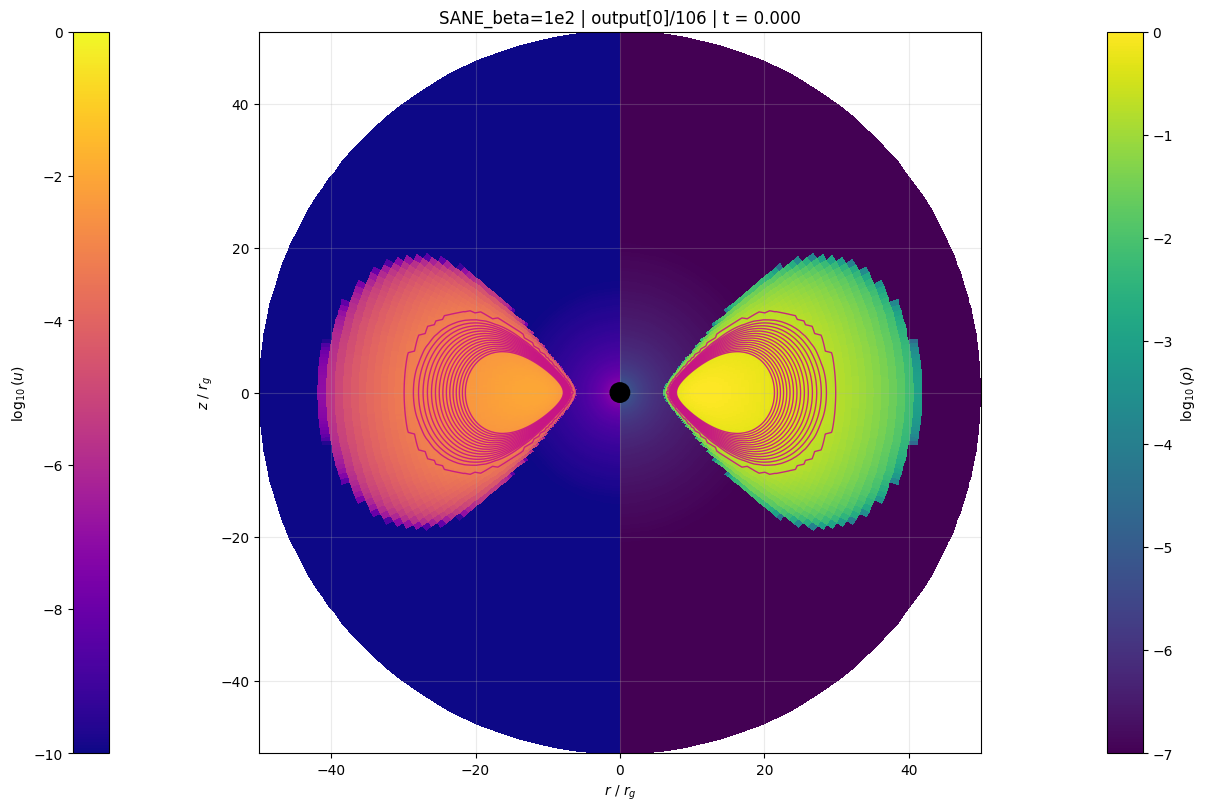

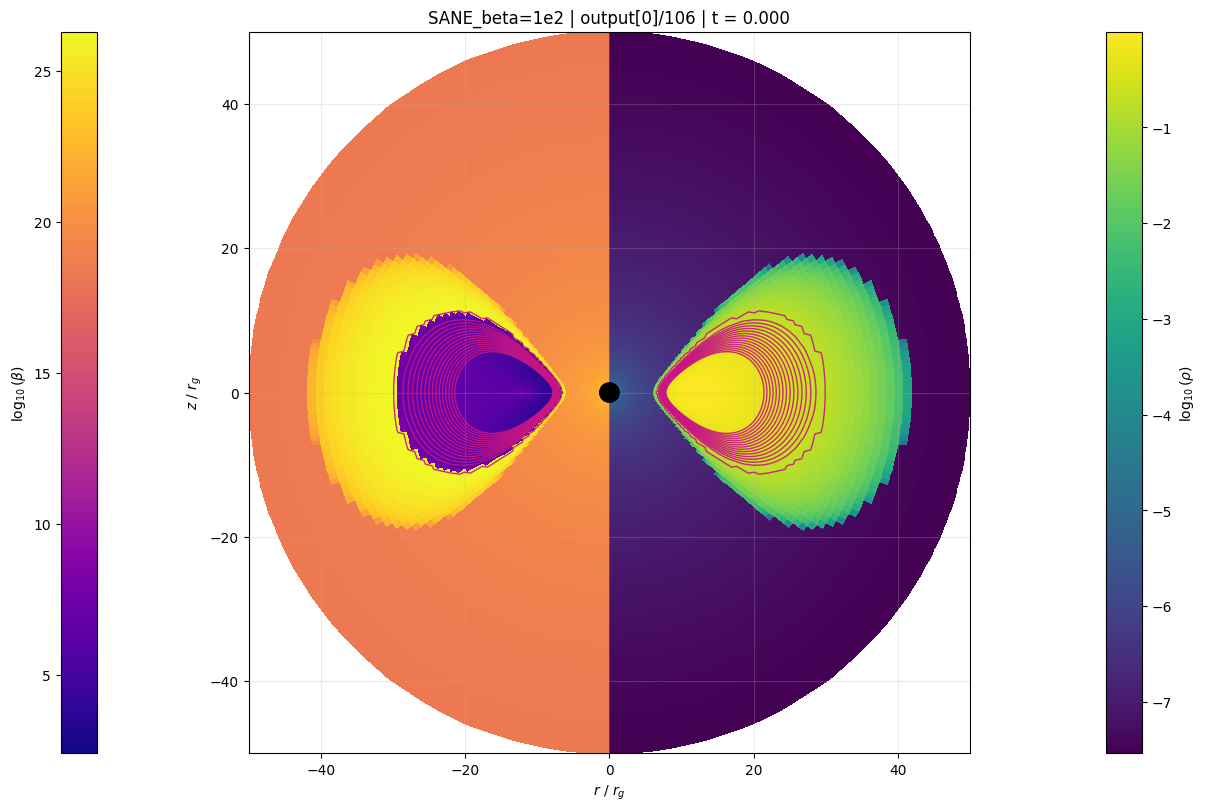

In [159]:
plot_primitives_rz(
    output_index=0,
    variables=("rho", "u"),
    var_labels=(r"$\rho$", r"$u$"),
    cmaps=("viridis", "plasma"),
    log_scale=(True, True),
    add_magnetic_contours=True,
    contour_levels=16,
    figsize=(12, 8),
    # vmin=[-7., -12.],
    vmin=[-7., -10.],
    vmax=[0., 0.],
);

plot_primitives_rz(
    output_index=0,
    variables=("rho", "beta"),
    var_labels=(r"$\rho$", r"$\beta$"),
    cmaps=("viridis", "plasma"),
    log_scale=(True, True),
    add_magnetic_contours=True,
    contour_levels=16,
    figsize=(12, 8),
    # vmin=[-7., -12.],
    # vmin=[-7., -10.],
    # vmax=[0., 0.],
);


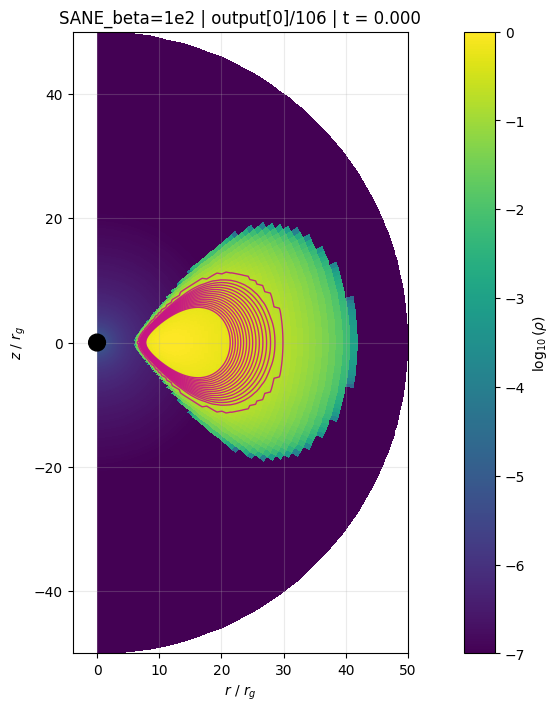

In [160]:
# Choose which output to plot via Python-style indexing:
# i = 0  -> first output (initial data)
# i = 3  -> fourth output
# i = -1 -> last output

i = 0
plot_primitives_rz(
    output_index=i,
    variables=("rho",),
    var_labels=(r"$\rho$",),
    cmaps=("viridis",),
    log_scale=True,
    add_magnetic_contours=True,
    contour_levels=16,
    figsize=(11, 7),
    vmin=[-7.,],
    vmax=[0.,],
);

# Example with derived variables: beta and sigma_rho
# plot_primitives_rz(
#     dump_file,
#     variables=("beta", "sigma_rho"),
#     var_labels=("plasma beta", "sigma_rho"),
#     cmaps=("hot", "cool"),
#     log_scale=(True, True),
#     figsize=(12, 8),
# );

In [161]:
def _resolve_dump_sequence(dump_file=None, available_dumps=None, start_index=None, stop_index=None, step=1):
    if step == 0:
        raise ValueError("step must be non-zero.")

    if available_dumps is None:
        if "dump_files" in globals() and len(globals()["dump_files"]) > 0:
            available_dumps = globals()["dump_files"]
        elif dump_file is not None:
            inferred = sorted(Path(dump_file).parent.glob("torus.out0.*.phdf"))
            available_dumps = inferred if inferred else [Path(dump_file)]
        else:
            available_dumps = []

    all_dumps = sorted(Path(path) for path in available_dumps)
    numbered = []
    for path in all_dumps:
        match = re.search(r"\.out0\.(\d+)\.phdf$", path.name)
        if match:
            numbered.append((int(match.group(1)), path))
    if numbered:
        all_dumps = [path for _, path in sorted(numbered, key=lambda item: item[0])]
    if not all_dumps:
        raise FileNotFoundError("No dump files available for movie generation.")

    selected_dumps = all_dumps[slice(start_index, stop_index, step)]
    if not selected_dumps:
        raise ValueError("Selected dump range produced no frames.")

    index_lookup = {path: idx for idx, path in enumerate(all_dumps)}
    selected_indices = [index_lookup[path] for path in selected_dumps]
    return selected_dumps, selected_indices, all_dumps


def make_primitives_rz_movie(
    output_file="primitives_rz_movie.mp4",
    dump_file=None,
    available_dumps=None,
    start_index=None,
    stop_index=None,
    step=1,
    variables=("rho",),
    var_labels=None,
    log_scale=True,
    log_floor=1e-30,
    cmaps=("viridis", "plasma"),
    vmin=None,
    vmax=None,
    add_magnetic_contours=True,
    contour_levels=20,
    contour_color="mediumvioletred",
    contour_alpha=0.9,
    phi_index=0,
    show_horizon=True,
    figsize=(12, 8),
    fps=10,
    dpi=120,
    bitrate=1800,
    overwrite=False,
    verbose=True,
    gamma=4.0/3.0,
):
    """
    Make an MP4 movie using the same cylindrical r-z plotting style as plot_primitives_rz.


    By default, this writes all available outputs to an MP4 in the run directory.
    Use start_index, stop_index, and step to make shorter previews or subsampled movies.
    
    Parameters
    ----------
    gamma : float, optional
        Adiabatic index for derived variables (beta, sigma_rho, sigma_w). Default: 4/3.
    """
    if not writers.is_available("ffmpeg"):
        raise RuntimeError("ffmpeg is not available to Matplotlib, so MP4 export cannot run.")

    if isinstance(variables, str):
        variables = [variables]
    else:
        variables = list(variables)
        glue_hemispheres = True

    if len(variables) < 1 or len(variables) > 2:
        raise ValueError("Pass one or two variable names in 'variables'.")

    if isinstance(cmaps, str):
        cmaps = [cmaps]
    else:
        cmaps = list(cmaps)
    if len(cmaps) < len(variables):
        cmaps += [cmaps[-1]] * (len(variables) - len(cmaps))

    def _expand_arg(arg, n):
        if isinstance(arg, (list, tuple, np.ndarray)):
            if len(arg) != n:
                raise ValueError(f"Expected {n} entries, got {len(arg)}")
            return list(arg)
        return [arg] * n

    log_flags = _expand_arg(log_scale, len(variables))
    vmins = _expand_arg(vmin, len(variables))
    vmaxs = _expand_arg(vmax, len(variables))

    labels = list(variables) if var_labels is None else list(var_labels)
    if len(labels) != len(variables):
        raise ValueError("Length of var_labels must match number of variables.")

    selected_dumps, selected_indices, all_dumps = _resolve_dump_sequence(
        dump_file=dump_file,
        available_dumps=available_dumps,
        start_index=start_index,
        stop_index=stop_index,
        step=step,
    )

    output_path = Path(output_file)
    if not output_path.is_absolute():
        # Save relative paths to the top-level runs directory, not inside a run folder.
        dump_parent = selected_dumps[0].parent.resolve()
        runs_root = next((p for p in [dump_parent] + list(dump_parent.parents) if p.name == "runs"), dump_parent)
        output_path = runs_root / output_path
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and not overwrite:
        raise FileExistsError(
            f"Output movie already exists: {output_path}. Pass overwrite=True to replace it."
        )

    par_files = sorted(selected_dumps[0].parent.glob("*.par"))
    par_cfg = _read_par_file(par_files[0]) if par_files else {}

    # Check if any requested variables are derived
    derived_vars = {var for var in variables if _resolve_primitive(var)[0] == "derived"}

    need_scanned_limits = [vmins[i] is None or vmaxs[i] is None for i in range(len(variables))]
    if any(need_scanned_limits):
        scanned_mins = [np.inf] * len(variables)
        scanned_maxs = [-np.inf] * len(variables)
        if verbose:
            print(f"Scanning {len(selected_dumps)} frames for color limits...")

        for dump_path in selected_dumps:
            with h5py.File(dump_path, "r") as fh:
                y_edges_blk = fh["Locations/y"][:]
                order = np.argsort(y_edges_blk[:, 0])

                # Pre-load primitives for derived variables if needed
                rho_2d, u_2d, b1_2d, b2_2d, b3_2d = None, None, None, None, None
                if derived_vars:
                    rho_arr_blk = _load_primitive_2d(fh, "prims.rho", component=None, phi_index=phi_index)
                    rho_2d = np.concatenate([rho_arr_blk[b] for b in order], axis=0)
                    
                    u_arr_blk = _load_primitive_2d(fh, "prims.u", component=None, phi_index=phi_index)
                    u_2d = np.concatenate([u_arr_blk[b] for b in order], axis=0)
                    
                    b1_arr_blk = _load_primitive_2d(fh, "prims.B", component=0, phi_index=phi_index)
                    b1_2d = np.concatenate([b1_arr_blk[b] for b in order], axis=0)
                    
                    b2_arr_blk = _load_primitive_2d(fh, "prims.B", component=1, phi_index=phi_index)
                    b2_2d = np.concatenate([b2_arr_blk[b] for b in order], axis=0)
                    
                    b3_arr_blk = _load_primitive_2d(fh, "prims.B", component=2, phi_index=phi_index)
                    b3_2d = np.concatenate([b3_arr_blk[b] for b in order], axis=0)
                    
                    beta, sigma_rho, sigma_w, bsq = _compute_beta_sigma(
                        rho_2d, u_2d, b1_2d, b2_2d, b3_2d, gamma=gamma
                    )
                    derived_arrays = {
                        "beta": beta,
                        "sigma_rho": sigma_rho,
                        "sigma_w": sigma_w,
                    }

                for i_var, var in enumerate(variables):
                    if not need_scanned_limits[i_var]:
                        continue
                    ds_name, comp, _ = _resolve_primitive(var)
                    
                    if ds_name == "derived":
                        arr = derived_arrays[var.lower()]
                    else:
                        arr_blk = _load_primitive_2d(fh, ds_name, component=comp, phi_index=phi_index)
                        arr = np.concatenate([arr_blk[block] for block in order], axis=0)

                    if log_flags[i_var]:
                        arr = np.log10(np.maximum(arr, log_floor))

                    local_min = float(np.nanmin(arr))
                    local_max = float(np.nanmax(arr))
                    if np.isfinite(local_min):
                        scanned_mins[i_var] = min(scanned_mins[i_var], local_min)
                    if np.isfinite(local_max):
                        scanned_maxs[i_var] = max(scanned_maxs[i_var], local_max)

        for i_var in range(len(variables)):
            if vmins[i_var] is None and np.isfinite(scanned_mins[i_var]):
                vmins[i_var] = scanned_mins[i_var]
            if vmaxs[i_var] is None and np.isfinite(scanned_maxs[i_var]):
                vmaxs[i_var] = scanned_maxs[i_var]

    base_coord_cfg = {
        "transform": str(par_cfg.get("coordinates/transform", "mks")).lower(),
        "hslope": float(par_cfg.get("coordinates/hslope", 0.3)),
        "mks_smooth": float(par_cfg.get("coordinates/mks_smooth", 0.5)),
        "poly_xt": float(par_cfg.get("coordinates/poly_xt", 0.82)),
        "poly_alpha": float(par_cfg.get("coordinates/poly_alpha", 14.0)),
        "a": float(par_cfg.get("coordinates/a", 0.0)),
    }

    fig = plt.figure(figsize=figsize, constrained_layout=False)
    writer = FFMpegWriter(
        fps=fps,
        metadata={"artist": "GitHub Copilot", "title": output_path.name},
        bitrate=bitrate,
    )

    if verbose:
        print(f"Writing {len(selected_dumps)} frames to {output_path}...")

    with writer.saving(fig, str(output_path), dpi=dpi):
        for frame_number, (dump_path, resolved_index) in enumerate(
            zip(selected_dumps, selected_indices), start=1
        ):
            dump_time = _read_dump_time(dump_path)

            with h5py.File(dump_path, "r") as fh:
                x_edges_blk = fh["Locations/x"][:]
                y_edges_blk = fh["Locations/y"][:]

                if "VolumeLocations/x" in fh:
                    x_centers_blk = fh["VolumeLocations/x"][:]
                else:
                    x_centers_blk = 0.5 * (x_edges_blk[:, :-1] + x_edges_blk[:, 1:])

                if "VolumeLocations/y" in fh:
                    y_centers_blk = fh["VolumeLocations/y"][:]
                else:
                    y_centers_blk = 0.5 * (y_edges_blk[:, :-1] + y_edges_blk[:, 1:])

                order = np.argsort(y_edges_blk[:, 0])
                x_edges = x_edges_blk[order[0]]
                x_centers = x_centers_blk[order[0]]
                y_edges = np.concatenate(
                    [y_edges_blk[block][:-1] for block in order] + [y_edges_blk[order[-1]][-1:]]
                )
                y_centers = np.concatenate([y_centers_blk[block] for block in order])

                # Pre-load primitives for derived variables if needed
                rho_2d, u_2d, b1_2d, b2_2d, b3_2d = None, None, None, None, None
                if derived_vars:
                    rho_arr_blk = _load_primitive_2d(fh, "prims.rho", component=None, phi_index=phi_index)
                    rho_2d = np.concatenate([rho_arr_blk[b] for b in order], axis=0)
                    
                    u_arr_blk = _load_primitive_2d(fh, "prims.u", component=None, phi_index=phi_index)
                    u_2d = np.concatenate([u_arr_blk[b] for b in order], axis=0)
                    
                    b1_arr_blk = _load_primitive_2d(fh, "prims.B", component=0, phi_index=phi_index)
                    b1_2d = np.concatenate([b1_arr_blk[b] for b in order], axis=0)
                    
                    b2_arr_blk = _load_primitive_2d(fh, "prims.B", component=1, phi_index=phi_index)
                    b2_2d = np.concatenate([b2_arr_blk[b] for b in order], axis=0)
                    
                    b3_arr_blk = _load_primitive_2d(fh, "prims.B", component=2, phi_index=phi_index)
                    b3_2d = np.concatenate([b3_arr_blk[b] for b in order], axis=0)
                    
                    beta, sigma_rho, sigma_w, bsq = _compute_beta_sigma(
                        rho_2d, u_2d, b1_2d, b2_2d, b3_2d, gamma=gamma
                    )
                    derived_arrays = {
                        "beta": beta,
                        "sigma_rho": sigma_rho,
                        "sigma_w": sigma_w,
                    }

                fields = []
                for var in variables:
                    ds_name, comp, _ = _resolve_primitive(var)
                    
                    if ds_name == "derived":
                        fields.append(derived_arrays[var.lower()])
                    else:
                        arr_blk = _load_primitive_2d(fh, ds_name, component=comp, phi_index=phi_index)
                        fields.append(np.concatenate([arr_blk[block] for block in order], axis=0))

                b1_blk = None
                if add_magnetic_contours:
                    b_ds, b_comp, _ = _resolve_primitive("B1")
                    b_arr_blk = _load_primitive_2d(fh, b_ds, component=b_comp, phi_index=phi_index)
                    b1_blk = np.concatenate([b_arr_blk[block] for block in order], axis=0)

            coord_cfg = dict(base_coord_cfg)
            coord_cfg["startx1"] = float(
                par_cfg.get(
                    "coordinates/fmks_zero_point",
                    par_cfg.get("parthenon/mesh/x1min", float(x_edges[0])),
                )
            )

            X1e, X2e = np.meshgrid(x_edges, y_edges)
            X1c, X2c = np.meshgrid(x_centers, y_centers)
            r_edges, th_edges = _native_to_r_theta(X1e, X2e, coord_cfg)
            r_cent, th_cent = _native_to_r_theta(X1c, X2c, coord_cfg)

            flux = None
            contour_vals = None
            if add_magnetic_contours and b1_blk is not None:
                flux = _metric_flux_from_b1(
                    b1_blk,
                    y_centers,
                    dump_path,
                    order,
                    phi_index=phi_index,
                    warn_on_fallback=(verbose and frame_number == 1),
                )
                qlo, qhi = [float(v) for v in np.nanquantile(flux, [0.1, 0.9])]
                if not np.isfinite(qlo) or not np.isfinite(qhi) or np.isclose(qlo, qhi):
                    qlo, qhi = float(np.nanmin(flux)), float(np.nanmax(flux))
                if np.isfinite(qlo) and np.isfinite(qhi):
                    qlo, qhi = max(min(qlo, qhi), 1e-5), max(qlo, qhi, 1e-5)
                    if not np.isclose(qlo, qhi):
                        contour_vals = np.linspace(qlo, qhi, int(contour_levels))

            fig.clear()
            ax = fig.add_subplot(111)
            if len(variables) == 2:
                fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.10)
            else:
                fig.subplots_adjust(left=0.10, right=0.90, top=0.93, bottom=0.10)


            exs = [0.0]
            if len(variables) == 2:
                exs = [0.0, np.pi] if glue_hemispheres else [0.0, 0.0]

            ims = []
            plotted_labels = []
            for i_var, field in enumerate(fields):
                show_data = np.array(field, copy=True)
                cb_label = labels[i_var]

                if log_flags[i_var]:
                    show_data = np.log10(np.maximum(show_data, log_floor))
                    cb_label = rf"$\log_{{10}}$({cb_label})"

                ex = exs[i_var]
                r_cyl_edges = r_edges * np.sin(th_edges + ex)
                z_edges = r_edges * np.cos(th_edges + ex) * np.cos(ex)

                im = ax.pcolormesh(
                    r_cyl_edges,
                    z_edges,
                    show_data,
                    shading="auto",
                    cmap=cmaps[i_var],
                    vmin=vmins[i_var],
                    vmax=vmaxs[i_var],
                )
                ims.append(im)
                plotted_labels.append(cb_label)

                if contour_vals is not None:
                    r_cyl_cent = r_cent * np.sin(th_cent + ex)
                    z_cent = r_cent * np.cos(th_cent + ex) * np.cos(ex)
                    ax.contour(
                        r_cyl_cent,
                        z_cent,
                        flux,
                        levels=contour_vals,
                        colors=contour_color,
                        linewidths=1.0,
                        alpha=contour_alpha,
                    )

            if len(ims) == 1:
                fig.colorbar(ims[0], ax=ax, label=plotted_labels[0], location="right")
            else:
                fig.colorbar(ims[0], ax=ax, label=plotted_labels[0], location="right", pad=0.08)
                cbar_left = fig.colorbar(ims[1], ax=ax, label=plotted_labels[1], location="left", pad=0.12)
                cbar_left.ax.yaxis.set_label_position("left")
                cbar_left.ax.yaxis.set_ticks_position("left")
                cbar_left.ax.tick_params(labelleft=True, labelright=False)

            if show_horizon:
                a_spin = coord_cfg["a"]
                r_h = 1.0 + np.sqrt(max(0.0, 1.0 - a_spin * a_spin))
                ax.add_patch(plt.Circle((0.0, 0.0), r_h, color="black", zorder=5))

            # title_vars = ", ".join(pl for pl in plotted_labels)
            title_vars = f"{run_label}"
            title_vars += f" | output[{resolved_index}]/{len(all_dumps) - 1}"
            if dump_time is not None:
                title_vars += f" | t = {dump_time:.3f}"

            ax.set_xlabel(r"$r$ / $r_g$")
            ax.set_ylabel(r"$z$ / $r_g$")
            ax.set_title(title_vars)
            ax.set_aspect("equal")
            ax.grid(alpha=0.25)

            writer.grab_frame()

            if verbose:
                print(
                    f"  rendered frame {frame_number}/{len(selected_dumps)}: {dump_path.name}",
                    end="\r",
                )

    plt.close(fig)

    if verbose:
        print()
        print(f"Saved movie to {output_path}")

    return output_path


In [ ]:
# Example movie calls:

# # Full movie using all outputs with rho
# make_primitives_rz_movie(
#     output_file="rhoWALD.mp4",
#     variables=("rho",),
#     var_labels=(r"$\rho$",),
#     fps=10,
#     vmin=[-7.,],
#     vmax=[0.,],
#     overwrite=True,
# )

# Two-variable movie
make_primitives_rz_movie(
    output_file=run_meta[run_selector_key]["movie_rsr"],
    variables=("rho", "sigma_rho"),
    var_labels=(r"$\rho$", r"$\sigma_{\rho}$"),
    fps=10,
    vmin=[-7., -8.],
    vmax=[0., 1.],
    overwrite=True,
)

# Two-variable movie
make_primitives_rz_movie(
    output_file=run_meta[run_selector_key]["movie_rb"],
    variables=("rho", "beta"),
    var_labels=(r"$\rho$", r"$\beta$"),
    fps=10,
    vmin=[-7., -2.],
    vmax=[0., 6.5],
    overwrite=True,
)

Writing 107 frames to /home/aaron/Research/kharma/runs/rho_sigma_rhoSANE.mp4...
  rendered frame 107/107: torus.out0.00106.phdf
Saved movie to /home/aaron/Research/kharma/runs/rho_sigma_rhoSANE.mp4
Writing 107 frames to /home/aaron/Research/kharma/runs/rho_betaSANE.mp4...
  rendered frame 107/107: torus.out0.00106.phdf
Saved movie to /home/aaron/Research/kharma/runs/rho_betaSANE.mp4


PosixPath('/home/aaron/Research/kharma/runs/rho_betaSANE.mp4')